# Historical Fires Analysis (2012-2023)
This notebook fetches historical fire polygons for British Columbia between 2012 and 2023, then clips them to the Cariboo Fire Centre boundaries and visualizes the fire points for 2023.

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import requests
from io import BytesIO

In [2]:
# Load Official Cariboo Fire Centre Boundaries
zones_wfs_url = "https://openmaps.gov.bc.ca/geo/pub/WHSE_LEGAL_ADMIN_BOUNDARIES.DRP_MOF_FIRE_ZONES_SP/ows"
params_zones = {
    "service": "WFS",
    "version": "2.0.0",
    "request": "GetFeature",
    "typeName": "WHSE_LEGAL_ADMIN_BOUNDARIES.DRP_MOF_FIRE_ZONES_SP",
    "outputFormat": "application/json",
    "CQL_FILTER": "MOF_FIRE_CENTRE_NAME='Cariboo Fire Centre'"
}

print("Fetching Cariboo Boundaries...")
response_zones = requests.get(zones_wfs_url, params=params_zones)
cariboo_gdf = gpd.read_file(BytesIO(response_zones.content))
cariboo_gdf = cariboo_gdf.to_crs(epsg=3005)
cariboo_gdf.head()

Fetching Cariboo Boundaries...


,id,MOF_FIRE_ZONE_ID,MOF_FIRE_CENTRE_NAME,MOF_FIRE_ZONE_NAME,HEADQUARTERS_CITY_NAME,OBJECTID,SE_ANNO_CAD_DATA,FEATURE_AREA_SQM,FEATURE_LENGTH_M,geometry
0,WHSE_LEGAL_ADMIN_BOUNDARIES.DRP_MOF_FIRE_ZONES...,493,Cariboo Fire Centre,100 Mile House Fire Zone,100 Mile House,1104,None,1.236059e+10,7.452190e+05,"POLYGON ((1365595.79 811388.999, 1365587.148 8..."
1,WHSE_LEGAL_ADMIN_BOUNDARIES.DRP_MOF_FIRE_ZONES...,496,Cariboo Fire Centre,Chilcotin Fire Zone,Williams Lake,1107,None,2.871304e+10,1.146598e+06,"POLYGON ((1176324.025 842019.703, 1176323.53 8..."
2,WHSE_LEGAL_ADMIN_BOUNDARIES.DRP_MOF_FIRE_ZONES...,498,Cariboo Fire Centre,Quesnel Fire Zone,Quesnel,1109,None,2.077233e+10,1.337766e+06,"POLYGON ((1264933.277 942501.98, 1264888.802 9..."
3,WHSE_LEGAL_ADMIN_BOUNDARIES.DRP_MOF_FIRE_ZONES...,510,Cariboo Fire Centre,Central Cariboo Fire Zone,Williams Lake,1121,None,2.063411e+10,1.316524e+06,"POLYGON ((1393202.155 890463.295, 1393201.79 8..."


In [3]:
# Load Historical Fires (2012-2023)
fires_wfs_url = "https://openmaps.gov.bc.ca/geo/pub/WHSE_LAND_AND_NATURAL_RESOURCE.PROT_HISTORICAL_FIRE_POLYS_SP/ows"
params_fires = {
    "service": "WFS",
    "version": "2.0.0",
    "request": "GetFeature",
    "typeName": "WHSE_LAND_AND_NATURAL_RESOURCE.PROT_HISTORICAL_FIRE_POLYS_SP",
    "outputFormat": "application/json",
    "CQL_FILTER": "FIRE_YEAR >= 2012 AND FIRE_YEAR <= 2023"
}

print("Fetching Historical Fires (2012-2023). This may take a moment...")
response_fires = requests.get(fires_wfs_url, params=params_fires)
historical_fires_gdf = gpd.read_file(BytesIO(response_fires.content))

if historical_fires_gdf.crs is None:
    historical_fires_gdf = historical_fires_gdf.set_crs(epsg=3005)
else:
    historical_fires_gdf = historical_fires_gdf.to_crs(epsg=3005)

print(f"Total historical fires loaded: {len(historical_fires_gdf)}")
historical_fires_gdf.head()

Fetching Historical Fires (2012-2023). This may take a moment...
Total historical fires loaded: 4389


,id,FIRE_NUMBER,VERSION_NUMBER,FIRE_YEAR,FIRE_CAUSE,FIRE_LABEL,FIRE_SIZE_HECTARES,SOURCE,GPS_TRACK_DATE,LOAD_DATE,FIRE_DATE,CREATION_METHOD,FEATURE_CODE,OBJECTID,SE_ANNO_CAD_DATA,FEATURE_AREA_SQM,FEATURE_LENGTH_M,geometry
0,WHSE_LAND_AND_NATURAL_RESOURCE.PROT_HISTORICAL...,G73561,NaN,2023,Unknown,2023-G73561,5.0,Non-corrected ground GPS,NaT,NaT,NaT,NaN,JA70003000,3207371,None,5.015902e+04,2035.1685,"POLYGON ((1273872.347 1166282.642, 1273873.95 ..."
1,WHSE_LAND_AND_NATURAL_RESOURCE.PROT_HISTORICAL...,G80536,2.012100e+09,2012,Lightning,2012-G80536,166.3,OZIX,2012-10-01,2012-10-01,2012-08-22,GPS-TRACK,JA70003000,3228253,None,1.663593e+06,8509.4061,"POLYGON ((1306997.084 1476404.179, 1306989.095..."
2,WHSE_LAND_AND_NATURAL_RESOURCE.PROT_HISTORICAL...,G90019,2.012091e+09,2012,Person,2012-G90019,2.4,OZIX,2012-05-02,2012-09-11,2012-05-01,GPS-TRACK,JA70003000,3228254,None,2.497856e+04,2056.6234,"POLYGON ((963168.597 1624076.147, 963170.23 16..."
3,WHSE_LAND_AND_NATURAL_RESOURCE.PROT_HISTORICAL...,C50006,2.012042e+09,2012,Person,2012-C50006,1.4,OZIX,2012-04-17,2012-04-17,2012-04-09,GPS-TRACK,JA70003000,3228182,None,1.463526e+04,649.9171,"POLYGON ((1194845.413 780018.415, 1194848.019 ..."
4,WHSE_LAND_AND_NATURAL_RESOURCE.PROT_HISTORICAL...,C50014,2.012043e+09,2012,Person,2012-C50014,0.2,OZIX,2012-05-03,2012-05-03,2012-04-24,GPS-TRACK,JA70003000,3228183,None,2.058982e+03,194.9144,"POLYGON ((1194737.676 779677.161, 1194722.28 7..."


In [4]:
# Filter for Cariboo Fire Centre
cariboo_historical_fires = gpd.sjoin(historical_fires_gdf, cariboo_gdf, how="inner", predicate="intersects")
print(f"Total historical fires in Cariboo region (2012-2023): {len(cariboo_historical_fires)}")

Total historical fires in Cariboo region (2012-2023): 660


In [6]:
print("total fires by cause:")
print(cariboo_historical_fires['FIRE_CAUSE'].value_counts())

total fires by cause:
FIRE_CAUSE
Lightning    395
Person       265
Name: count, dtype: int64


burnet area histogram:


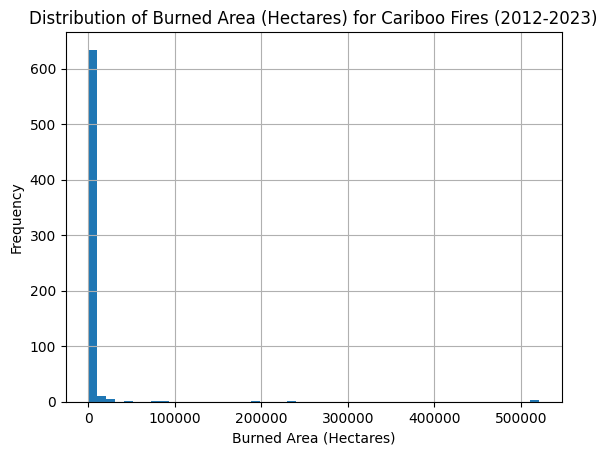

In [ ]:
print("burnet area histogram:")
cariboo_historical_fires['FIRE_SIZE_HECTARES'].hist(bins=50)
plt.title("Distribution of Burned Area (Hectares) for Cariboo Fires (2012-2023)")
plt.xlabel("Burned Area (Hectares)")
plt.ylabel("Frequency")
plt.show()  


In [16]:
import numpy as np

burned are histogram after log transformation:


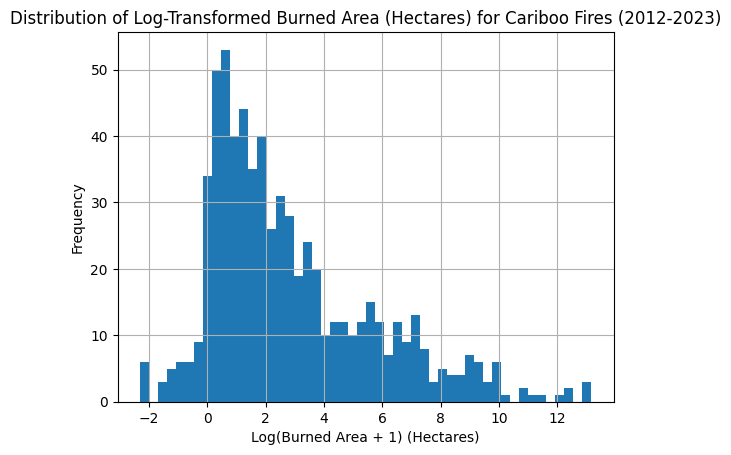

In [17]:
print("burned are histogram after log transformation:")
cariboo_historical_fires['FIRE_SIZE_HECTARES'].apply(lambda x: x if x <= 0 else np.log(x)).hist(bins=50)
plt.title("Distribution of Log-Transformed Burned Area (Hectares) for Cariboo Fires (2012-2023)")
plt.xlabel("Log(Burned Area + 1) (Hectares)")
plt.ylabel("Frequency")
plt.show()

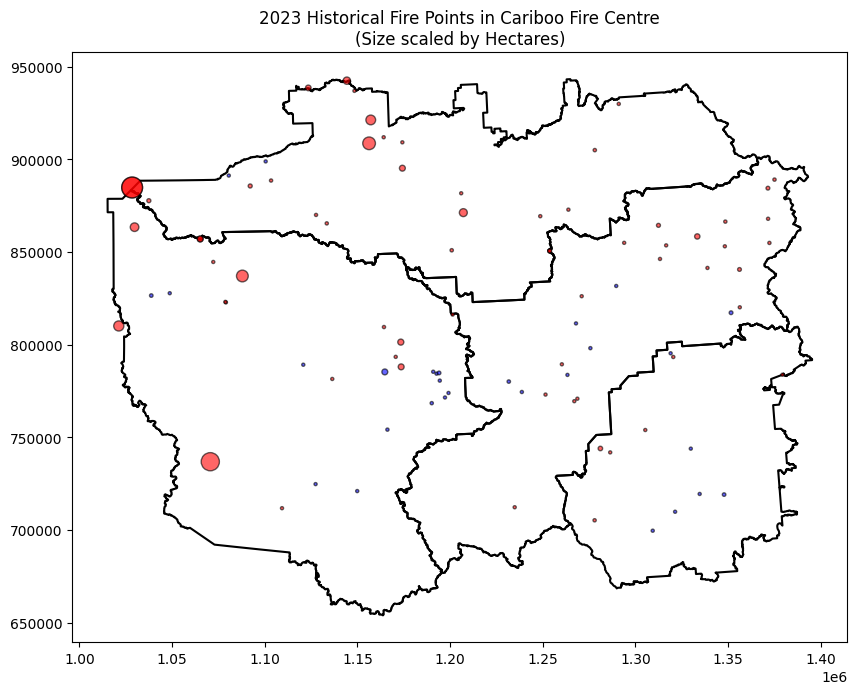

total area burned in 2023: 106857.49999999999 hectares


In [13]:
# Plot points with FIRE_SIZE_HECTARES for Cariboo boundaries for 2023
fires_2023 = cariboo_historical_fires[cariboo_historical_fires['FIRE_YEAR'] == 2023].copy()

# Convert polygons to points (centroids) for point plotting
fires_2023['geometry'] = fires_2023.geometry.centroid

fig, ax = plt.subplots(figsize=(10, 10))

# Plot Cariboo Boundaries
cariboo_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.5, zorder=1)

sizes = fires_2023['FIRE_SIZE_HECTARES'].fillna(0) / 100 + 5 
#blue marker is for human caused fires, red for natural causes, and grey for unknown causes
colors = fires_2023['FIRE_CAUSE'].map({
    'Person': 'blue',
    'Lightning': 'red',
    'Unknown': 'grey'
}).fillna('grey')
fires_2023.plot(ax=ax, markersize=sizes, color=colors, alpha=0.6, edgecolor='k', zorder=2)

ax.set_title("2023 Historical Fire Points in Cariboo Fire Centre\n(Size scaled by Hectares)")
plt.show()
print("total area burned in 2023:", fires_2023['FIRE_SIZE_HECTARES'].sum(), "hectares")

In [19]:
print("total fires where burned area was zero and less than 100 hectares for all years:")
print("zero hectares:", len(cariboo_historical_fires[cariboo_historical_fires['FIRE_SIZE_HECTARES'] == 0]))
print("less than 100 hectares:", len(cariboo_historical_fires[cariboo_historical_fires['FIRE_SIZE_HECTARES'] < 100]))


total fires where burned area was zero and less than 100 hectares for all years:
zero hectares: 3
less than 100 hectares: 506
